Best so far

Data successfully loaded!
Data collection complete. Ready for plotting.

       MEAN BEST-SO-FAR AIC MILESTONES

--- Delphos ---
  Mean reaches minimum at       : attempt 1239  (AIC = 7438.59)
  Mean first drops below 7500 at: attempt 132 (AIC = 7498.57)

--- SA ---
  Mean reaches minimum at       : attempt 1414  (AIC = 7451.98)
  Mean first drops below 7500 at: attempt 400 (AIC = 7493.53)

--- VNS ---
  Mean reaches minimum at       : attempt 1483  (AIC = 7757.55)
  Mean first drops below 7500 at: Never reaches below 7500


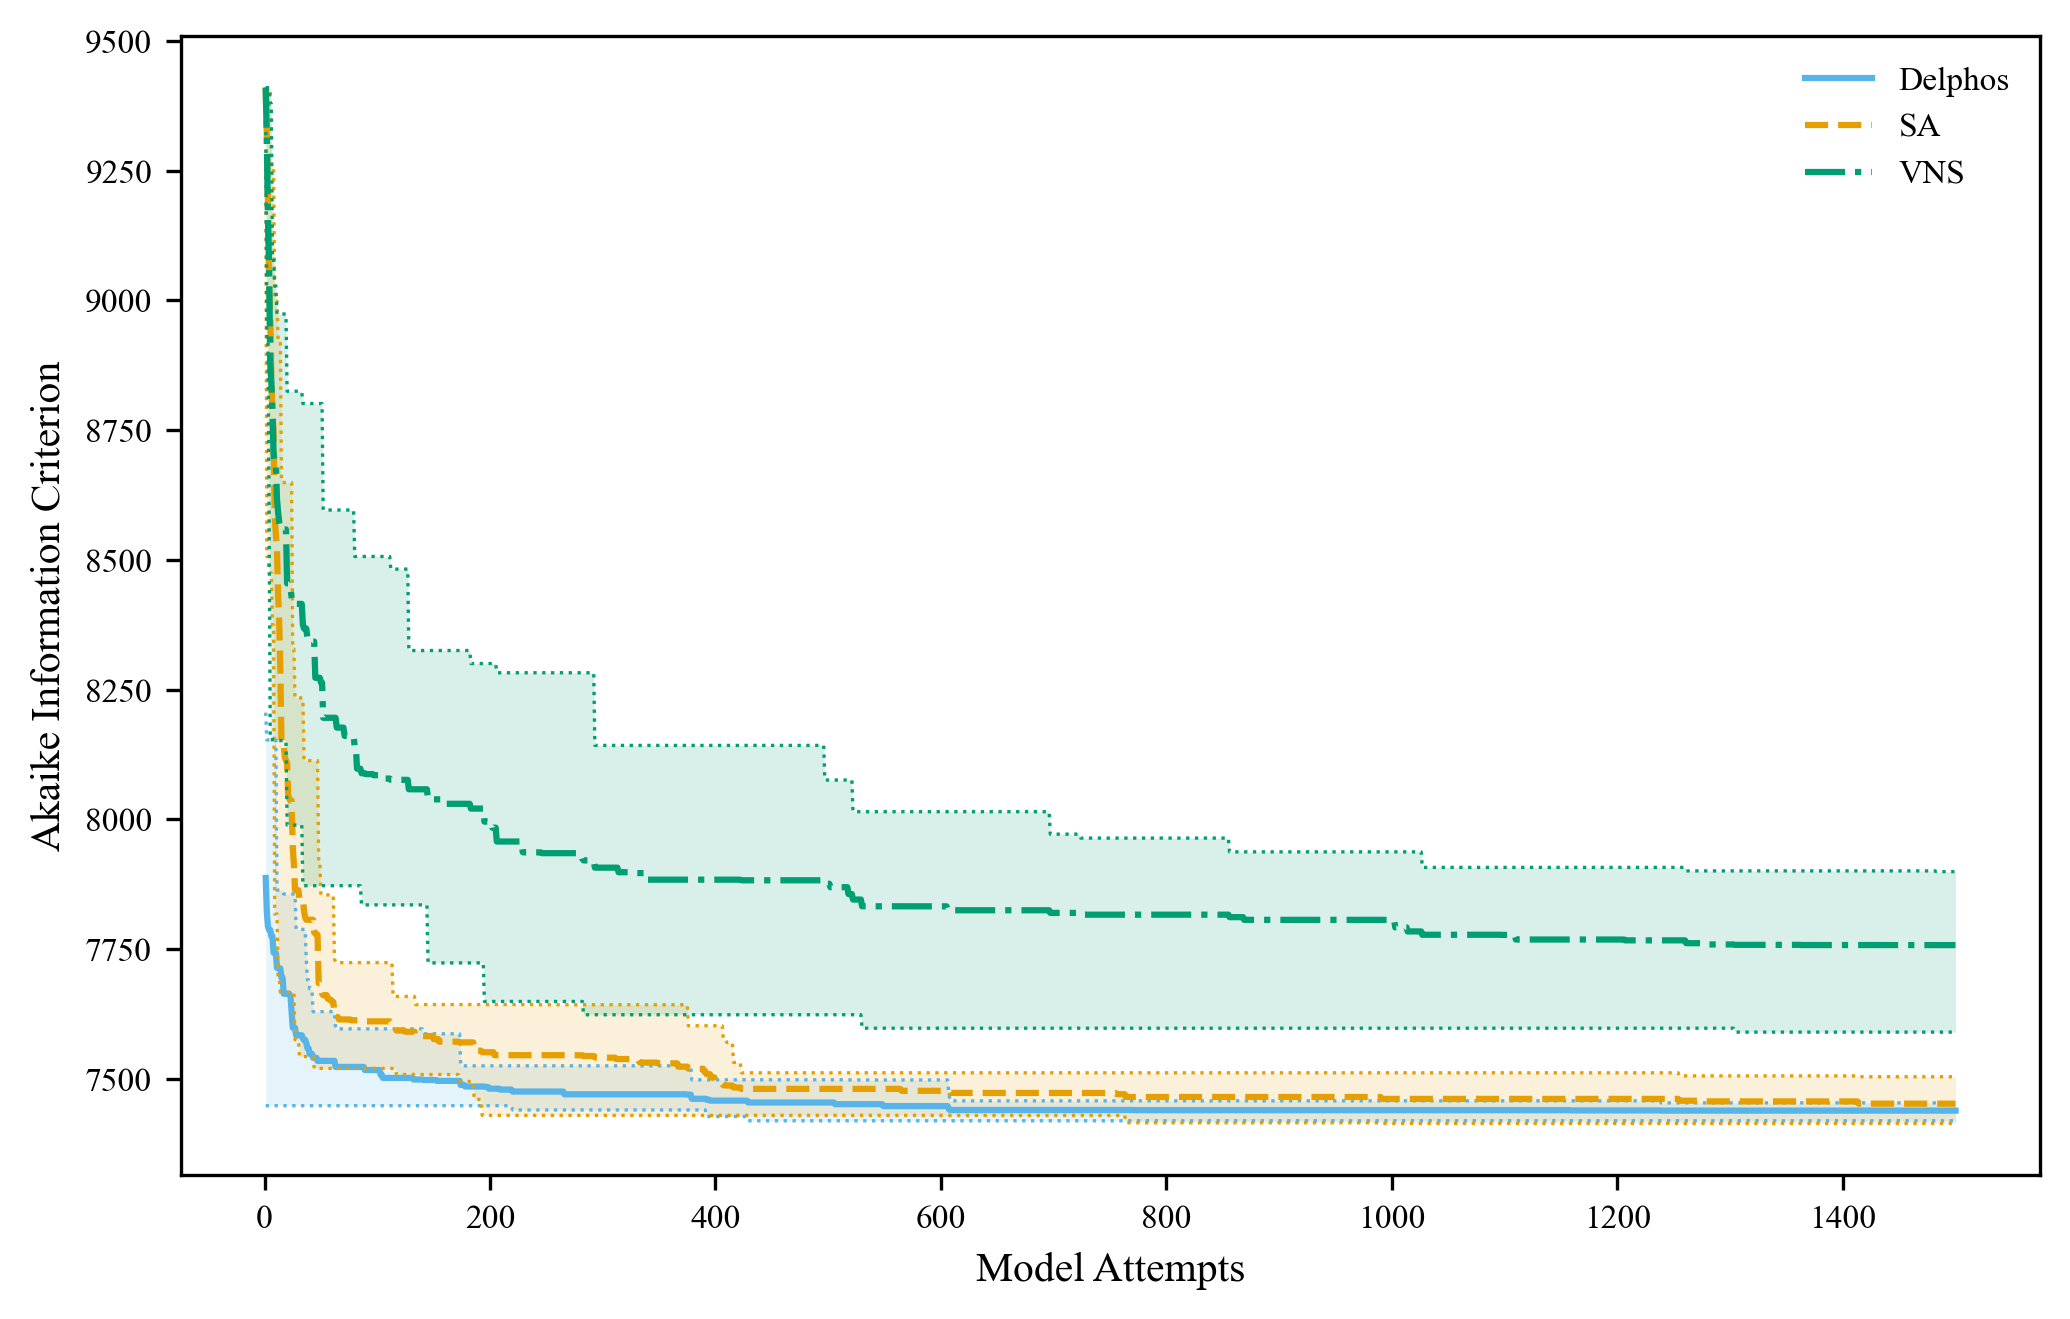

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path

# ==============================================================================
# 1. SETTINGS
# ==============================================================================
plt.rcParams.update({
    "font.family": "serif",               # Serif fonts
    "font.serif": ["Times New Roman", "Computer Modern Roman", "serif"],
    "font.size": 10,                      # Base font size
    "axes.titlesize": 10,                 
    "axes.labelsize": 10,                 # Axis labels
    "xtick.labelsize": 8,                 # X-axis ticks
    "ytick.labelsize": 8,                 # Y-axis ticks
    "legend.fontsize": 8,                 # Legend font size
    "axes.spines.top": True,             # Clean look (remove top box line)
    "axes.spines.right": True,           # Clean look (remove right box line)
    "figure.dpi": 300,                    # High resolution 
    "savefig.bbox": "tight",
})

base_dir = str(Path.cwd().parent)
methods = ["Delphos", "SA", "VNS"]
seeds = [f"seed_{i}" for i in range(101, 111)]
max_attempt = 1500 
budget = f"B_{max_attempt}"

data_collection = {method: [] for method in methods}

# --- 1: Collect the Data ---
for method in methods:
    for seed in seeds:        
        if method == "Delphos":
            filename = "models_new.csv"
        else:
            filename = "estimations.csv"
            
        file_path = os.path.join(base_dir, method, budget, seed, filename)                 
        if not os.path.exists(file_path):
            print(f"File not found: {file_path}")
            continue
            
        try:
            if method == "Delphos":
                df = pd.read_csv(file_path, usecols=['attempt', 'AIC'])
                
            elif method == "SA":
                df = pd.read_csv(file_path, usecols=['attempt', 'aic'])
                df['AIC'] = df['aic'] 
                df = df[['attempt', 'AIC']]
                
            elif method == "VNS":
                df = pd.read_csv(file_path, usecols=['attempt', 'log_likelihood', 'parameters'])
                df['AIC'] = 2 * df['parameters'] - 2 * df['log_likelihood']
                df = df[['attempt', 'AIC']] 
            
            df = df.sort_values('attempt').reset_index(drop=True)            
            df['best_AIC'] = df['AIC'].cummin()                        
            best_aic_series = df.set_index('attempt')['best_AIC']
            data_collection[method].append(best_aic_series)            
        except Exception as e:
            print(f"Error processing {file_path}: {e}")
print("Data successfully loaded!")

# --- 2: Mean and Std ---
method_stats = {}
attempt_grid = np.arange(1, max_attempt + 1)
for method, series_list in data_collection.items():
    if not series_list:
        continue
        
    aligned_series = []
    for s in series_list:       
        s_aligned = s.reindex(attempt_grid).ffill()
        s_aligned = s_aligned.bfill()
        aligned_series.append(s_aligned.values)
        
    aligned_array = np.vstack(aligned_series)
    mean_aic = np.nanmean(aligned_array, axis=0)
    std_aic = np.nanstd(aligned_array, axis=0)
    ci_95 = 1.96 * (std_aic / np.sqrt(10))
    min_aic = np.nanmin(aligned_array, axis=0)
    max_aic = np.nanmax(aligned_array, axis=0)

    method_stats[method] = {
    'mean': mean_aic, 'std': std_aic, 'ci': ci_95,
    'min': min_aic, 'max': max_aic, 'attempts': attempt_grid
    }

print("Data collection complete. Ready for plotting.")

# --- 2b: the mean best-so-far curve ---
print("\n" + "=" * 65)
print("       MEAN BEST-SO-FAR AIC MILESTONES")
print("=" * 65)

for method in methods:
    if method not in method_stats:
        continue
    stats = method_stats[method]
    mean = stats['mean']
    attempts = stats['attempts']
    
    min_idx = np.argmin(mean)
    min_attempt = attempts[min_idx]
    min_value = mean[min_idx]
    
    below_mask = np.where(mean < 7500)[0]
    if len(below_mask) > 0:
        first_below_idx = below_mask[0]
        first_below_attempt = attempts[first_below_idx]
        first_below_value = mean[first_below_idx]
        below_str = f"attempt {first_below_attempt} (AIC = {first_below_value:.2f})"
    else:
        below_str = "Never reaches below 7500"
    
    print(f"\n--- {method} ---")
    print(f"  Mean reaches minimum at       : attempt {min_attempt}  (AIC = {min_value:.2f})")
    print(f"  Mean first drops below 7500 at: {below_str}")


# --- 3: Plot ---
COLORS = {
        'Delphos': '#56B4E9', # Sky Blue
        'SA':      '#E69F00', # Orange
        'VNS':     '#009E73', # Bluish Green
    }

LINE_STYLES = {
    'Delphos': '-',   # Solid line
    'SA':      '--',  # Dashed line
    'VNS':     '-.',  # Dotted line
}

fig, ax = plt.subplots(figsize=(7, 4.5))

for method in ['Delphos', 'SA', 'VNS']:
    if method not in method_stats:
        continue
    stats = method_stats[method]
    mean     = stats['mean']
    std      = stats['std']
    ci       = stats['ci']  
    attempts = stats['attempts']
    color    = COLORS[method]
    style    = LINE_STYLES[method]

    # Mean curve (solid thick line)
    ax.plot(
        attempts, mean,
        color=color, linestyle=style, lw=1.5,
        label=f'{method}', zorder=2
    )

    # Max curve (worst seed)
    ax.plot(
        attempts, stats['max'],
        color=color, linestyle=':', lw=0.8,
        alpha=1, zorder=2
    )
    
    # Min curve (best seed) - Re-enabled so the shadow has a clean boundary!
    ax.plot(
        attempts, stats['min'],
        color=color, linestyle=':', lw=0.8,
        alpha=1, zorder=2
    )

    # Min–Max shading
    ax.fill_between(
        attempts, stats['min'], stats['max'],
        alpha=0.15, color=color, linewidth=0, zorder=0
    )

ax.set_xlabel('Model Attempts')
ax.set_ylabel('Akaike Information Criterion')
ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useOffset=False))
ax.ticklabel_format(style='plain', axis='y')
ax.legend(frameon=False, loc='upper right')

plt.tight_layout()
plt.savefig(f'swissmetro_AIC_best_methods.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()